<a href="https://colab.research.google.com/github/Yesmin55/reservation_ticket/blob/master/Premiers_pas_avec_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IA générative (IIT 2026-2027)**
## **Premiers pas avec PyTorch — Atelier guidé**

**Objectif :** construire un petit CNN pour MNIST et comprendre *ce que fait chaque instruction importante*.



**Importation des modules**


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchsummary import summary

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

## 1-2/ Chargement et transformation des données MNIST

MNIST contient des images en **niveaux de gris de taille 28×28**.  
Ici, `Resize((28,28))` n'apporte rien : les images MNIST ont déjà cette taille, donc on le retire pour garder l'exemple minimal.

- `ToTensor()` : image → tenseur PyTorch ;
- `Normalize()` : normalise les valeurs ;
- `DataLoader` : construit des **batches** ;
- `shuffle=True` uniquement pour le jeu d'entraînement.

In [4]:
# =========================
# Transformation des images
# =========================
transform = transforms.Compose([
    transforms.ToTensor(),   #convertir l'image en Tensor
    transforms.Normalize((0.1307,), (0.3081,)) ])

# =========================
# Téléchargement des datasets
# =========================
full_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# 54 000 images pour l'entraînement, 6 000 pour la validation
train_dataset, val_dataset = random_split(full_train_dataset,[54000, 6000])

# =========================
# DataLoaders
# =========================
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True )

val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 37.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 993kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.4MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.68MB/s]


### 🔎 Avant d'exécuter...

Avec `batch_size=64`, des images en niveaux de gris et une taille 28×28 :

**Quelle forme attendez-vous pour `imgs` ?** `[?, ?, ?, ?]`


PyTorch représente un lot d'images avec : <b>[batch, channels, height, width]</b>.


In [5]:
imgs, labels = next(iter(train_loader))

print("Type :", type(imgs))
print("Shape images :", imgs.shape)
print("Shape labels :", labels.shape)

Type : <class 'torch.Tensor'>
Shape images : torch.Size([64, 1, 28, 28])
Shape labels : torch.Size([64])


## 3 / Définition du modèle CNN


**<u>Calcul indispensable</u>**

Après les deux poolings, Que contient l’entrée de la première couche Linear ?




In [6]:
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu=nn.ReLU()

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(3136, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)


        x = self.flatten(x)

        x = self.fc1(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x

> **Pourquoi pas de `Softmax` à la fin ?**  
> `nn.CrossEntropyLoss()` attend directement les **logits** produits par `fc2`. Elle intègre le calcul nécessaire pour la classification multi-classe.


## 4 / Device et résumé de l'architecture


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

model = MyModel().to(device)

# Forme d'une image MNIST : (channels, height, width)
summary(model, (1, 28, 28))

Device utilisé : cpu
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
         MaxPool2d-4           [-1, 32, 14, 14]               0
            Conv2d-5           [-1, 64, 14, 14]          18,496
       BatchNorm2d-6           [-1, 64, 14, 14]             128
              ReLU-7           [-1, 64, 14, 14]               0
         MaxPool2d-8             [-1, 64, 7, 7]               0
           Flatten-9                 [-1, 3136]               0
           Linear-10                  [-1, 128]         401,536
      BatchNorm1d-11                  [-1, 128]             256
             ReLU-12                  [-1, 128]               0
           Linear-13                   [-1, 10]           1,290
Total params: 422,

## 5 / Fonction de perte et optimiseur

Deux rôles différents :

- **Loss** : mesure *à quel point la prédiction est mauvaise*.
- **Optimizer** : utilise les gradients pour *modifier les poids du réseau*.


In [8]:
# quelle loss pour une classification multi-classe ?
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

###  *Le cœur de PyTorch :*

Les cinq instructions conceptuellement importantes sont :

1. `outputs = model(images)` → **forward / prédiction**
2. `loss = criterion(outputs, labels)` → **mesure de l'erreur**
3. `optimizer.zero_grad()` → **remise à zéro des anciens gradients**
4. `loss.backward()` → **calcul des gradients**
5. `optimizer.step()` → **mise à jour des poids**


## 5 (Suite) / Entraînement + validation

In [11]:
def train(model, train_loader, val_loader, criterion, optimizer, epochs=10):

    for epoch in range(epochs):

        # =====================================================
        # 1) ENTRAÎNEMENT
        # =====================================================
        model.train()            # activer le mode entraînement

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(train_loader,desc=f"Époque {epoch+1}/{epochs}")

        for images, labels in progress_bar:

            images = images.to(device)
            labels = labels.to(device)

            # Forward
            outputs = model(images) #output.shape -> torch.size([64,20])

            # Calcul de l'erreur
            loss = criterion(outputs, labels)#labels.shape->torch.size{[64]}

            # Les gradients s'accumulent dans PyTorch
            optimizer.zero_grad()

            # Backpropagation
            loss.backward()

            # Mise à jour des paramètres
            optimizer.step()

            # Métriques d'entraînement
            running_loss += loss.item() * images.size(0)

            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total


        # =====================================================
        # 2) VALIDATION
        # =====================================================
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # pas de gradients en validation

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                predicted = outputs.argmax(dim=1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        print(f"Époque [{epoch+1}/{epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

### Lancement de l'entraînement


In [12]:
train(model, train_loader, val_loader, criterion, optimizer, epochs=10)

Époque 1/10: 100%|██████████| 844/844 [01:36<00:00,  8.75it/s]


Époque [1/10] Train Loss: 0.1109, Train Acc: 0.9735 | Val Loss: 0.0412, Val Acc: 0.9875


Époque 2/10: 100%|██████████| 844/844 [01:39<00:00,  8.46it/s]


Époque [2/10] Train Loss: 0.0365, Train Acc: 0.9887 | Val Loss: 0.0391, Val Acc: 0.9855


Époque 3/10: 100%|██████████| 844/844 [01:39<00:00,  8.48it/s]


...

Époque [8/10] Train Loss: 0.0079, Train Acc: 0.9974 | Val Loss: 0.0334, Val Acc: 0.9890


Époque 9/10: 100%|██████████| 844/844 [01:41<00:00,  8.30it/s]


Époque [9/10] Train Loss: 0.0059, Train Acc: 0.9982 | Val Loss: 0.0387, Val Acc: 0.9885


Époque 10/10: 100%|██████████| 844/844 [01:41<00:00,  8.30it/s]


Époque [10/10] Train Loss: 0.0058, Train Acc: 0.9982 | Val Loss: 0.0312, Val Acc: 0.9910


## 6 / Évaluation finale sur le jeu de test


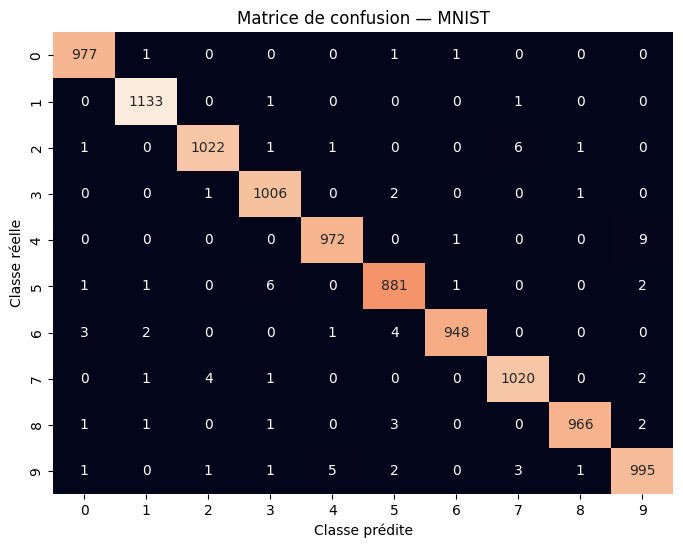

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = outputs.argmax(dim=1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cbar=False)
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion — MNIST")
plt.show()

***<u> Récapitulatif:</u>***

|  | Description |
|---|---|
| `DataLoader`  | Créer des batches et alimenter le modèle |
| `model(images)`  | Forward pass / calcul des prédictions |
| `criterion(...)`  | Calcul de la loss |
| `zero_grad()`  | Effacer les gradients du batch précédent |
| `backward()`  | Calculer les gradients |
| `optimizer.step()`  | Modifier les poids |
| `model.eval()`  | Passer le modèle en mode évaluation |
| `torch.no_grad()`  | Désactiver le calcul des gradients |
